# Introduction

This notebook implements a BERT deep learning model to classify reviews as suspicious or non suspicious. 

Unlike traditional machine learning models, BERT uses contextual language understanding to capture semantic patterns in text without requiring manual feature engineering.

The model is trained on raw review text using labels generated through a weak supervision approach, allowing it to learn deeper linguistic and contextual signals associated with suspicious behaviour. 

The performance of BERT is then evaluated and compared against traditional models such as Logistic Regression and Support Vector Machines.

This approach enables a comprehensive comparison between classical machine learning methods and transformer models for suspicious review detection.

In [1]:
# Install Necessary Libraries
!pip install transformers torch datasets scikit-learn joblib


In [42]:
# Import necessary libraries
import joblib
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import os

from collections import Counter
from datasets import Dataset
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding
)

from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score
from sklearn.utils.class_weight import compute_class_weight
from torch.nn import CrossEntropyLoss


## Load the data 

In [28]:
train_text = joblib.load("shared_suspicious/train_text.pkl")
test_text = joblib.load("shared_suspicious/test_text.pkl")

y_train = joblib.load("shared_suspicious/y_train.pkl")
y_test = joblib.load("shared_suspicious/y_test.pkl")

print("Train size:", len(train_text))
print("Test size:", len(test_text))

#original dataset# original data
df = pd.read_csv("Amazon_reviews_final.csv")

#load test index
test_index = joblib.load("shared_suspicious/test_indices.pkl")


Train size: 661918
Test size: 165480


### Create data frame

In [4]:
train_df = pd.DataFrame({
    "text": train_text,
    "label": y_train
})

test_df = pd.DataFrame({
    "text": test_text,
    "label": y_test
})


# Sample the data set for efficient training
train_df = train_df.sample(120000, random_state=42)
test_df = test_df.sample(30000, random_state=42)

print("Reduced train size:", len(train_df))
print("Reduced test size:", len(test_df))


train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

Reduced train size: 120000
Reduced test size: 30000


### Load Tokenizer

In [5]:
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

### Tokenization
Transforms each review into token IDs and attention masks while limiting sequence length for efficiency.

In [6]:
def tokenize(example):
    return tokenizer(
        example["text"],
        truncation=True,
        max_length=128 
    )

train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

Map:   0%|          | 0/120000 [00:00<?, ? examples/s]

Map:   0%|          | 0/30000 [00:00<?, ? examples/s]

### Padding
Applies padding dynamically during batching to reduce unnecessary computation and improve efficiency.

In [7]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

### Format dataset
Converts the dataset into PyTorch tensors required for model training.

In [8]:
train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
test_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

### Custom Trainer

In [9]:
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        
        loss_fct = CrossEntropyLoss(weight=class_weights.to(model.device))
        loss = loss_fct(logits, labels)
        
        return (loss, outputs) if return_outputs else loss

### Training settings

In [10]:
training_args = TrainingArguments(
    output_dir="./distilbert_results",

    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    logging_steps=500,

    dataloader_num_workers=2,

    fp16=True if torch.cuda.is_available() else False
)

### Compute Metrics

In [11]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds),
        "recall": recall_score(labels, preds)
    }

### Specify different weights

In [12]:
weight_options = [
    [1, 8],  
    [1, 15] 
]

### Training and threshold tuning loop

In [13]:
all_results = []

for weights in weight_options:
    
    print(f"\nTraining with weights: {weights}")
    
    # class weights
    class_weights = torch.tensor(weights, dtype=torch.float)
    
    # modelling
    model = DistilBertForSequenceClassification.from_pretrained(
        "distilbert-base-uncased",
        num_labels=2
    )
    
    # trainer
    trainer = WeightedTrainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=test_dataset,
        data_collator=data_collator,
        compute_metrics=compute_metrics
    )
    
    # train model
    trainer.train()
    
    # make predictions
    predictions = trainer.predict(test_dataset)
    logits = predictions.predictions
    probs = torch.softmax(torch.tensor(logits), dim=1)[:, 1].numpy()
    
    # threshold tuning
    thresholds = [0.1, 0.2, 0.3, 0.4]
    
    for threshold in thresholds:
        y_pred = (probs > threshold).astype(int)
        
        all_results.append({
            "weights": weights,
            "threshold": threshold,
            "precision": precision_score(test_df["label"], y_pred),
            "recall": recall_score(test_df["label"], y_pred),
            "f1": f1_score(test_df["label"], y_pred)
        })



Training with weights: [1, 8]


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/opt/miniconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
500,0.647225
1000,0.583877
1500,0.631681
2000,0.637262
2500,0.636885
3000,0.579940
3500,0.600910
4000,0.616031
4500,0.639191
5000,0.585382


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/opt/miniconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


### View results

In [14]:
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values(by="f1", ascending=False)

results_df.head(10)

,weights,threshold,precision,recall,f1
1,"[1, 8]",0.2,0.217742,0.071571,0.107731
0,"[1, 8]",0.1,0.050300,1.000000,0.095782
4,"[1, 15]",0.1,0.050300,1.000000,0.095782
5,"[1, 15]",0.2,0.050300,1.000000,0.095782
2,"[1, 8]",0.3,0.241379,0.051027,0.084245
3,"[1, 8]",0.4,0.278008,0.044400,0.076571
6,"[1, 15]",0.3,0.444444,0.002651,0.005270
7,"[1, 15]",0.4,0.444444,0.002651,0.005270


Although BERT is a powerful deep learning model capable of capturing contextual information in text, it underperformed compared to Logistic Regression and SVM in this task.

This is because the detection of suspicious reviews in this study relies heavily on behavioural and structured features, such as review frequency and verification status, rather than purely textual patterns. Since BERT only processes raw text, it is unable to capture these important signals.

Additionally, many suspicious reviews are linguistically similar to genuine reviews, making it difficult for text-based models to distinguish between classes. As a result, traditional models that incorporate engineered features demonstrated superior performance.

This highlights that model complexity does not necessarily guarantee better performance, and that model selection should be aligned with the nature of the data and features.

### Pick best model

In [15]:
best = results_df.iloc[0]

best_weights = best["weights"]
best_threshold = best["threshold"]

print("\nBest model:")
print(best)


Best model:
weights        [1, 8]
threshold         0.2
precision    0.217742
recall       0.071571
f1           0.107731
Name: 1, dtype: object


### Train Best Model

In [19]:
best_weights = [1, 8]
best_threshold = 0.2

class_weights = torch.tensor(best_weights, dtype=torch.float)

# modelling
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

# Load trainer
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    data_collator=data_collator
)

print("Training best model...")
trainer.train()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training best model...


/opt/miniconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
500,0.647966
1000,0.599594
1500,0.633045
2000,0.638499
2500,0.619069
3000,0.576000
3500,0.638207
4000,0.607201
4500,0.628323
5000,0.591940


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=15000, training_loss=0.6178006713867188, metrics={'train_runtime': 19835.7055, 'train_samples_per_second': 12.099, 'train_steps_per_second': 0.756, 'total_flos': 7384556582720832.0, 'train_loss': 0.6178006713867188, 'epoch': 2.0})

### Prediction and final eveluation

In [20]:
# prediction

predictions = trainer.predict(test_dataset)
logits = predictions.predictions

probs = torch.softmax(torch.tensor(logits), dim=1)[:, 1].numpy()

# Final eveluation
y_pred = (probs > best_threshold).astype(int)

print("\nFinal Metrics:")
print("Accuracy:", accuracy_score(test_df["label"], y_pred))
print("F1:", f1_score(test_df["label"], y_pred))
print("Recall:", recall_score(test_df["label"], y_pred))

/opt/miniconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)



Final Metrics:
Accuracy: 0.9212333333333333
F1: 0.20141939844542076
Recall: 0.19748177601060304


The BERT model achieved high accuracy but low F1-score and recall, indicating poor performance in detecting suspicious reviews.



### Feature importance
Due to the nature of BERT as a deep learning model, traditional feature importance techniques are not directly applicable. Instead, an approximate analysis was conducted by identifying frequently occurring words in reviews classified as suspicious.


In [21]:

# get predicted suspicious reviews
suspicious_indices = np.where(y_pred == 1)[0]

suspicious_texts = test_df.iloc[suspicious_indices]["text"]

# combine words
all_words = " ".join(suspicious_texts).split()

# count frequency
word_counts = Counter(all_words)

# top 20 words
top_words = word_counts.most_common(20)

print("\nTop words in suspicious reviews:")
print(top_words)


Top words in suspicious reviews:
[('the', 10697), ('and', 6055), ('of', 5244), ('to', 5026), ('I', 4478), ('a', 4269), ('is', 2927), ('in', 2710), ('that', 2242), ('this', 1884), ('was', 1829), ('it', 1737), ('for', 1596), ('with', 1384), ('book', 1372), ('as', 1298), ('The', 1262), ('have', 1217), ('are', 1032), ('but', 1031)]


The analysis of top words shows that the model focuses on common words rather than meaningful indicators of suspicious behaviour.



### Misclassification analysis
Get the false positive and false negative

In [22]:
# actual labels
y_true = test_df["label"].values

# false positives
false_positive_indices = np.where((y_pred == 1) & (y_true == 0))[0]

# false negatives
false_negative_indices = np.where((y_pred == 0) & (y_true == 1))[0]

### View Examples

In [24]:
print("\nFalse Positives (predicted suspicious but not suspicous):")
print(test_df.iloc[false_positive_indices[:5]]["text"])

print("\nFalse Negatives (missed suspicious reviews):")
print(test_df.iloc[false_negative_indices[:5]]["text"])


False Positives (predicted suspicious but not suspicous):
246171    First book was great, second - also loved it. ...
728706    Like the seasons before it, season 4 is full o...
672436    As an avid Harry Potter fan since 1998, I have...
427543    john adams was a very interesting epic.  the h...
185394    I loved the book and I love the series.  I can...
Name: text, dtype: object

False Negatives (missed suspicious reviews):
617757    Wow!  One of the best books I've read.  I foun...
707014    The final episode is rather depressing, but th...
757418    always come back to this brand because is for ...
359453    Great Book .I couldn't put this book down! A g...
93175     Our dog (a pitbull / boxer mix) has to have go...
Name: text, dtype: object


Misclassification analysis revealed that the model incorrectly flags normal positive reviews as suspicious, while missing suspicious reviews that appear natural. This suggests that BERT struggles to capture subtle patterns and relies heavily on surface level text features.

Overall, the results indicate that text alone is insufficient for detecting suspicious reviews, highlighting the importance of inlcuding behavioural features.

### Verified vs unverified reviews

In [ ]:

test_df = test_df.reset_index(drop=True)

#  reset df
df = df.reset_index(drop=True)

# attach verified column by position since the data set was sampled earlier
test_df["verified"] = df.loc[test_df.index, "verified"].values

In [35]:
y_pred = (probs > best_threshold).astype(int)

analysis_df = test_df.copy()
analysis_df["predicted"] = y_pred
analysis_df["verified"] = analysis_df["verified"].astype(int)

In [37]:
verified_df = analysis_df[analysis_df["verified"] == 1]
unverified_df = analysis_df[analysis_df["verified"] == 0]

verified_counts = verified_df["predicted"].value_counts().sort_index()
unverified_counts = unverified_df["predicted"].value_counts().sort_index()

# make sure both classes exist
verified_counts = verified_counts.reindex([0,1], fill_value=0)
unverified_counts = unverified_counts.reindex([0,1], fill_value=0)

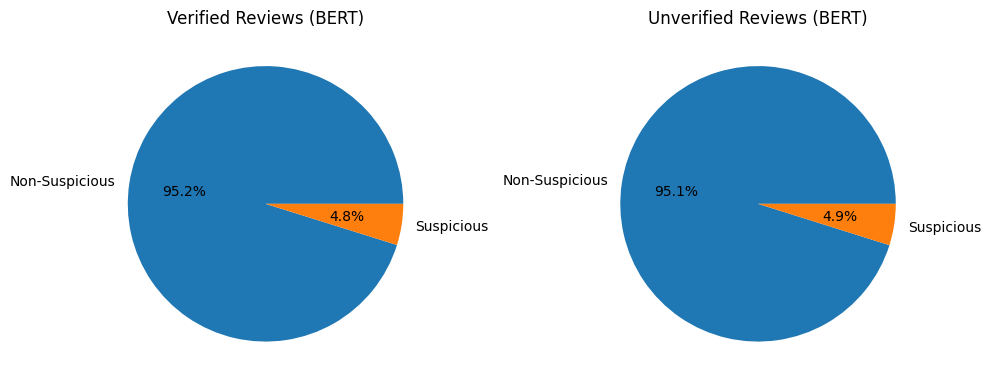

In [ ]:
# Plot the pie chart
labels = ["Non-Suspicious", "Suspicious"]

plt.figure(figsize=(10,5))

# verified
plt.subplot(1,2,1)
plt.pie(verified_counts, labels=labels, autopct='%1.1f%%')
plt.title("Verified Reviews (BERT)")

# unverified
plt.subplot(1,2,2)
plt.pie(unverified_counts, labels=labels, autopct='%1.1f%%')
plt.title("Unverified Reviews (BERT)")

plt.tight_layout()
plt.show()

The BERT model shows distributions for both verified and unverified reviews, with approximately 4.8 to 4.9% of reviews classified as suspicious in both groups.

This indicates that the model does not differentiate between verified and unverified reviews. Unlike other models, BERT relies solely on textual data and does not capture behavioural signals such as purchase verification.

As a result, the model was unable to make use of  verification status as an indicator of suspicious behaviour.

## Save final output

In [46]:
# create folder
os.makedirs("model_suspicious/bert_model", exist_ok=True)

# save bert
model.save_pretrained("model_suspicious/bert_model")
tokenizer.save_pretrained("model_suspicious/bert_model")

print("bert model saved.")

# predictions
y_pred = (probs > best_threshold).astype(int)

y_test = y_test[:len(y_pred)]

# evaluation
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

# save results
results = pd.DataFrame([{
    "model": "bert",
    "accuracy": accuracy,
    "f1_score": f1,
    "recall": recall
}])

results.to_csv("model_suspicious/bert_results.csv", index=False)

# save threshold
joblib.dump(best_threshold, "model_suspicious/bert_threshold.pkl")

print("model and results successfully.")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

bert model saved.
model and results successfully.
